<a href="https://colab.research.google.com/github/appgallery/Futsal-ML-Analysis/blob/main/Futsal_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sports Analytics & Match Prediction System

## Bussiness Objective

The goal of this project is to build a **Machine Learning–Driven Sports Analytics System** that predicts:

1. **Which team has the highest probability of winning today’s match**
2. **Which players are most likely to perform best during the match**
3. **Key match insights using historical match and player event data**

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [48]:
matches = pd.read_csv('/content/series-futsal-men-matches.csv')
scores = pd.read_csv('/content/players-futsal-men-scores.csv')

clean_matches = matches.copy()
clean_matches.head()

,match_id,cmp_id,homeTeamId,awayTeamId,startTime,endTime,startDate,startingTime,courtId,courtName,...,is_bye,note,is_forfeited,is_cancel,homeTeamKits,awayTeamKits,homeTeamName,awayTeamName,competitionName,seasonName
0,97881,430,331,17,1/20/2023 18:45,1/20/2023 20:00,1/20/2023,18:45:00,11,Series Futsal Arena,...,False,NaN,False,no,0,0,Hume FC,Fitzroy FC,2023/1 Series Futsal Victoria Men,2023/1
1,97882,430,21,19,1/20/2023 20:00,1/20/2023 21:15,1/20/2023,20:00:00,11,Series Futsal Arena,...,False,NaN,False,no,0,0,Campbellfield FC,Altona Knights FC,2023/1 Series Futsal Victoria Men,2023/1
2,97883,430,325,18,1/20/2023 21:15,1/20/2023 22:30,1/20/2023,21:15:00,11,Series Futsal Arena,...,False,NaN,False,no,0,0,Roxburgh Park Gorillas,Moreland Blues FC,2023/1 Series Futsal Victoria Men,2023/1
3,97884,430,22,20,2/21/2023 20:30,2/21/2023 21:45,2/21/2023,20:30:00,11,Series Futsal Arena,...,False,NaN,False,no,0,0,FC Carlton Heart,Western United FC,2023/1 Series Futsal Victoria Men,2023/1
4,97885,430,22,331,1/27/2023 18:45,1/27/2023 20:00,1/27/2023,18:45:00,11,Series Futsal Arena,...,False,NaN,False,no,0,0,FC Carlton Heart,Hume FC,2023/1 Series Futsal Victoria Men,2023/1


# Explority Data Analysis(EDA) for Match Series Dataset

### Finding total columns and row size

In [49]:
clean_matches.shape

(423, 34)

### Checking Datatypes

In [50]:
clean_matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   match_id           423 non-null    int64  
 1   cmp_id             423 non-null    int64  
 2   homeTeamId         423 non-null    int64  
 3   awayTeamId         423 non-null    int64  
 4   startTime          423 non-null    object 
 5   endTime            423 non-null    object 
 6   startDate          423 non-null    object 
 7   startingTime       423 non-null    object 
 8   courtId            423 non-null    int64  
 9   courtName          423 non-null    object 
 10  quaterFinal        0 non-null      float64
 11  semiFinals         0 non-null      float64
 12  final              0 non-null      float64
 13  referee_id         423 non-null    int64  
 14  winningTeam        423 non-null    int64  
 15  losingTeam         423 non-null    int64  
 16  winningTeamGoals   423 non

### Finding Distribution of Data

In [51]:
clean_matches.describe()

,match_id,cmp_id,homeTeamId,awayTeamId,courtId,quaterFinal,semiFinals,final,referee_id,winningTeam,losingTeam,winningTeamGoals,losingTeamGoals,winningTeamPoints,losingTeamPoints,round,note,homeTeamKits,awayTeamKits
count,423.000000,423.000000,423.000000,423.000000,423.000000,0.0,0.0,0.0,423.0,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,423.000000,0.0,423.000000,423.000000
mean,162484.829787,674.624113,119.271868,124.550827,11.163121,NaN,NaN,NaN,1.0,89.066194,154.756501,6.252955,2.437352,2.723404,0.035461,10.283688,NaN,0.841608,0.799054
std,51433.622887,194.117454,147.040518,148.962977,0.369913,NaN,NaN,NaN,0.0,131.824224,155.834855,3.236321,1.598348,0.827029,0.185161,6.003545,NaN,7.149783,7.014528
min,97881.000000,430.000000,16.000000,16.000000,11.000000,NaN,NaN,NaN,1.0,16.000000,16.000000,1.000000,0.000000,0.000000,0.000000,1.000000,NaN,0.000000,0.000000
25%,124020.500000,527.000000,18.000000,18.000000,11.000000,NaN,NaN,NaN,1.0,17.000000,19.000000,4.000000,1.000000,3.000000,0.000000,5.000000,NaN,0.000000,0.000000
50%,147871.000000,627.000000,20.000000,20.000000,11.000000,NaN,NaN,NaN,1.0,18.000000,22.000000,6.000000,2.000000,3.000000,0.000000,10.000000,NaN,0.000000,0.000000
75%,217713.500000,878.000000,325.000000,329.000000,11.000000,NaN,NaN,NaN,1.0,22.000000,331.000000,8.000000,3.000000,3.000000,0.000000,15.000000,NaN,0.000000,0.000000
max,250487.000000,1028.000000,355.000000,355.000000,12.000000,NaN,NaN,NaN,1.0,355.000000,355.000000,22.000000,8.000000,3.000000,1.000000,21.000000,NaN,101.000000,104.000000


### Checking Null Values

In [52]:
missing = clean_matches.isnull().sum()

missing[missing > 0].sort_values(
    ascending=False
)

,0
quaterFinal,423
semiFinals,423
final,423
note,423
is_forfeited,6


### Total Goals

In [53]:
clean_matches['total_goals'] = (clean_matches['winningTeamGoals'] + clean_matches['losingTeamGoals'])
clean_matches['total_goals']

,total_goals
0,6
1,11
2,5
3,3
4,6
...,...
418,10
419,7
420,5
421,6


In [54]:
clean_matches['total_goals'].describe()

,total_goals
count,423.000000
mean,8.690307
std,3.892644
min,1.000000
25%,6.000000
50%,8.000000
75%,11.000000
max,25.000000


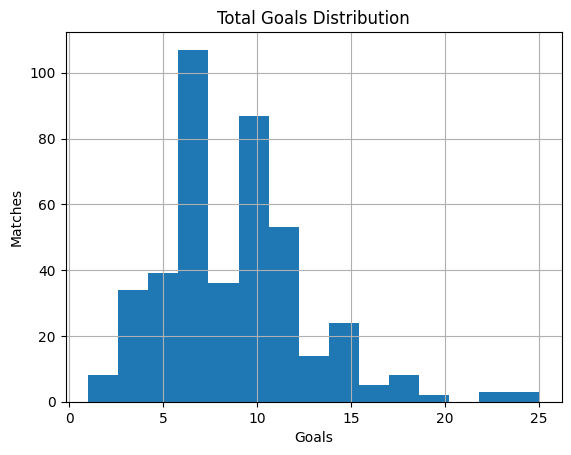

In [55]:
import matplotlib.pyplot as plt

clean_matches['total_goals'].hist(
    bins=15
)

plt.xlabel("Goals")
plt.ylabel("Matches")
plt.title("Total Goals Distribution")
plt.show()

### Goal Difference

In [56]:
clean_matches['goal_difference'] = (clean_matches['winningTeamGoals'] - clean_matches['losingTeamGoals'])
clean_matches['goal_difference']

,goal_difference
0,4
1,1
2,3
3,1
4,2
...,...
418,0
419,1
420,1
421,4


### Home Team Winner

In [57]:
clean_matches['home_win'] = (clean_matches['winningTeam'] == clean_matches['homeTeamId']).astype(int)
clean_matches['home_win']

,home_win
0,0
1,1
2,0
3,1
4,0
...,...
418,1
419,0
420,0
421,1


In [58]:
clean_matches['home_win'].value_counts()

,count
home_win,
1,231
0,192


In [59]:
clean_matches['home_win'].describe()

,home_win
count,423.000000
mean,0.546099
std,0.498460
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


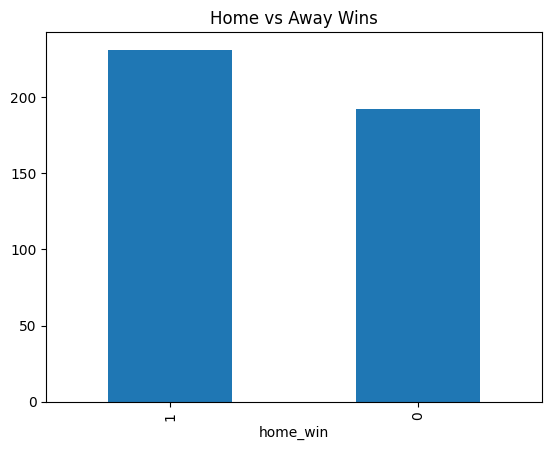

In [60]:
clean_matches['home_win'].value_counts().plot(
    kind='bar'
)

plt.title("Home vs Away Wins")
plt.show()

### Top Winnning Team

In [61]:
top_winners = (clean_matches['winningTeam'].value_counts().head(10))
print(top_winners)

winningTeam
17     106
18      91
331     50
20      29
19      28
16      28
21      27
22      19
329     12
355     11
Name: count, dtype: int64


### Top Loosing Team

In [62]:
top_losers = (clean_matches['losingTeam'].value_counts().head(10))
print(top_losers)

losingTeam
22     66
331    65
19     54
20     46
325    32
16     27
355    25
18     24
329    21
322    17
Name: count, dtype: int64


### Total Round Count

In [63]:
matches['round'].value_counts()

,count
round,
1,23
2,23
3,23
4,23
5,23
6,23
7,23
8,23
9,20


### Total CourtRoom Count

In [64]:
display(matches['courtName'].value_counts())

,count
courtName,
Series Futsal Arena,336
Series Futsal Darebin Court 3&4,69
Series Futsal Darebin Court 1&2,18


### Finding Correlation Among Data

In [65]:
corr = matches.select_dtypes(
    include=['int64', 'float64']
).corr()
corr

,match_id,cmp_id,homeTeamId,awayTeamId,courtId,quaterFinal,semiFinals,final,referee_id,winningTeam,losingTeam,winningTeamGoals,losingTeamGoals,winningTeamPoints,losingTeamPoints,round,note,homeTeamKits,awayTeamKits
match_id,1.000000,0.998117,0.081877,0.109039,0.582515,NaN,NaN,NaN,NaN,0.087839,0.107182,0.025835,0.025002,0.058394,0.263639,-0.172191,NaN,0.201853,0.195359
cmp_id,0.998117,1.000000,0.082831,0.111864,0.589819,NaN,NaN,NaN,NaN,0.090429,0.108592,0.016782,0.024727,0.057035,0.263756,-0.193806,NaN,0.214791,0.207863
homeTeamId,0.081877,0.082831,1.000000,-0.100573,0.111235,NaN,NaN,NaN,NaN,0.519522,0.407953,-0.047536,0.041326,0.000893,0.006608,-0.023925,NaN,0.036727,-0.001298
awayTeamId,0.109039,0.111864,-0.100573,1.000000,0.106220,NaN,NaN,NaN,NaN,0.314659,0.594828,-0.040512,0.021061,0.038921,-0.056124,-0.072182,NaN,0.031952,-0.025441
courtId,0.582515,0.589819,0.111235,0.106220,1.000000,NaN,NaN,NaN,NaN,0.113539,0.110448,0.038690,0.047384,-0.007087,0.261318,-0.296183,NaN,-0.026943,-0.006516
quaterFinal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
semiFinals,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
final,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
referee_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
winningTeam,0.087839,0.090429,0.519522,0.314659,0.113539,NaN,NaN,NaN,NaN,1.000000,-0.054936,-0.163534,0.101936,-0.074646,0.051358,-0.035305,NaN,0.004471,-0.006997


### Team Strength Analysis

In [67]:
total_wins = clean_matches['home_win'].sum()
total_matches = len(matches)
team_strength = (total_wins / total_matches)
print(f"Team Strength (overall home win rate): {team_strength:.2f}")

Team Strength (overall home win rate): 0.55


### Average Goal Difference per Match

In [68]:
goals_scored = clean_matches['winningTeamGoals'].mean()
goals_conceded = clean_matches['losingTeamGoals'].mean()
avg_goal_diff = (
    goals_scored -
    goals_conceded
)
print(f"Average Goal Difference Per Match: {avg_goal_diff:.2f}")

Average Goal Difference Per Match: 3.82


# Data Transformation

### Droping the unused columns

In [69]:
drop_cols = [
    'quaterFinal',
    'semiFinals',
    'final',
    'note'
]

clean_matches.drop(columns=drop_cols, inplace=True)

### Taking data which is for is_cancel and is_forefeited != True otherwise delete of column

In [70]:
clean_matches = clean_matches[clean_matches['is_forfeited'] != True]

clean_matches = clean_matches[clean_matches['is_cancel'] != True]

### Data Transformation for Categorical to Numerical

In [71]:
bool1_cols = ['isDraw','last_match','is_cancel']

for col in bool1_cols:
    clean_matches[col] = (clean_matches[col].astype(str).str.lower().map({ 'yes': 1, 'no': 0 }))

In [72]:
bool2_cols = ['is_forfeited', 'is_bye']

for col in bool2_cols:
    clean_matches[col] = (clean_matches[col].astype(str).str.strip().str.upper().eq('TRUE').astype(int))

### Changing Datatype of Start Date

In [73]:
clean_matches['startDate'] = pd.to_datetime(
    clean_matches['startDate'],
    errors='coerce'
)

In [74]:
clean_matches['match_year'] = (
    clean_matches['startDate'].dt.year
)

clean_matches['match_month'] = (
    clean_matches['startDate'].dt.month
)

clean_matches['match_day'] = (
    clean_matches['startDate'].dt.day
)

clean_matches['match_weekday'] = (
    clean_matches['startDate'].dt.weekday
)

### Adding Total Goal, Goal Difference, Home Win Columns

In [75]:
# CREATE TOTAL GOALS FEATURE
clean_matches['total_goals'] = (
    clean_matches['winningTeamGoals'] +
    clean_matches['losingTeamGoals']
)

# CREATE GOAL DIFFERENCE FEATURE
clean_matches['goal_difference'] = (
    clean_matches['winningTeamGoals'] -
    clean_matches['losingTeamGoals']
)

# CREATE HOME WIN TARGET
clean_matches['home_win'] = (
    clean_matches['winningTeam'] ==
    clean_matches['homeTeamId']
).astype(int)

### Adding Home Team and Away Team Goal Column

In [76]:
# HOME TEAM GOALS
clean_matches['home_team_goals'] = np.where(
    clean_matches['winningTeam'] ==
    clean_matches['homeTeamId'],

    clean_matches['winningTeamGoals'],
    clean_matches['losingTeamGoals']
)

# AWAY TEAM GOALS
clean_matches['away_team_goals'] = np.where(
    clean_matches['winningTeam'] ==
    clean_matches['awayTeamId'],

    clean_matches['winningTeamGoals'],
    clean_matches['losingTeamGoals']
)

### Adding Home Team and Away Team Points Columns

In [77]:
# HOME TEAM POINTS
clean_matches['home_team_points'] = np.where(
    clean_matches['winningTeam'] ==
    clean_matches['homeTeamId'],

    clean_matches['winningTeamPoints'],
    clean_matches['losingTeamPoints']
)

# AWAY TEAM POINTS
clean_matches['away_team_points'] = np.where(
    clean_matches['winningTeam'] ==
    clean_matches['awayTeamId'],

    clean_matches['winningTeamPoints'],
    clean_matches['losingTeamPoints']
)

### Removing Leakage and Unused Columns

In [78]:
# REMOVING LEAKAGE COLUMNS

leakage_cols = [
    'winningTeam',
    'losingTeam',
    'winningTeamGoals',
    'losingTeamGoals',
    'winningTeamPoints',
    'losingTeamPoints'
]

clean_matches.drop(
    columns=leakage_cols,
    inplace=True,
    errors='ignore'
)

In [79]:
# REMOVE UNUSED TEXT COLUMNS

unused_cols = [
    'startTime',
    'endTime',
    'startingTime',
    'courtName',
    'status',
    'competitionName',
    'seasonName'
]

clean_matches.drop(
    columns=unused_cols,
    inplace=True,
    errors='ignore'
)

In [80]:
# FINAL MISSING VALUE CHECK
print(clean_matches.isnull().sum())

# FINAL DATASET INFO
print(clean_matches.info())

# FINAL DATASET SHAPE
print(clean_matches.shape)

# FINAL DATASET PREVIEW
print(clean_matches.head())

match_id            0
cmp_id              0
homeTeamId          0
awayTeamId          0
startDate           0
courtId             0
referee_id          0
round               0
isDraw              0
last_match          0
is_bye              0
is_forfeited        0
is_cancel           0
homeTeamKits        0
awayTeamKits        0
homeTeamName        0
awayTeamName        0
total_goals         0
goal_difference     0
home_win            0
match_year          0
match_month         0
match_day           0
match_weekday       0
home_team_goals     0
away_team_goals     0
home_team_points    0
away_team_points    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   match_id          423 non-null    int64         
 1   cmp_id            423 non-null    int64         
 2   homeTeamId        423 non-null    int64      

In [81]:
# SAVE CLEAN DATASET
clean_matches.to_csv(
    "final_clean_matches.csv",
    index=False
)

print("\nFinal cleaned dataset saved as:")
print("final_clean_matches.csv")


Final cleaned dataset saved as:
final_clean_matches.csv
